# Timeseries tutorial

### Objectives

By the end of this tutorial...
1. 
2.
3.


### Methodology

input: 
> - IGR shapefiles
> - DAMIP temperature 2D data
> - Worldpop population data


Use exact extract for daily mean temperature, and population mean temperature 

In [ ]:
# exact extract steps is going to be a walkthrough
# relying on subprocess working
# think about a workaround on a basic dataset for plan b

In [ ]:
# Task

# 1. compare DAMIP raw to downscaled for regions in Salvador

# 2. compare hist to hist nat for downscaled data in Salvador 

# 3. choose region of choice for something else

In [ ]:
link = 'https://fiocruzbr-my.sharepoint.com/:u:/g/personal/taisa_cortes_fiocruz_br/IQC3_oBBith0TojO0uytGejTAcpYWCNB7Jxh4n7hOgIJWog?e=q2nZd4'

In [ ]:
# Emily
# TODO: set up colab
# TODO: upload all shapefiles to google drive
# TODO: upload all other relevant files to google drive


In [ ]:
# import python packages
import xarray as xr
import pandas as pd
import gdown
import xarray as xr
import h5py
import numpy as np
import matplotlib.pyplot as plt
from exactextract import exact_extract
import geopandas as gpd
import rioxarray

In [ ]:
# download tutorial data from google drive link
# TODO: extend to full link of relevant datasets, calling them the matching name to our local files
# gdown.download(
#     "https://drive.google.com/uc?id=1M7I18GpCAOEEwD87mi8GrgwELveZzKli",
#     "myfile.nc",
#     quiet=False
# )

In [ ]:
# open downscaled data
downscaled = xr.open_dataset("tas_downscaled_05x05_2000_2018.nc", engine="netcdf4")

# crop the edge to match pop density format
downscaled = downscaled.isel(lat=slice(1,83), lon=slice(1,83))

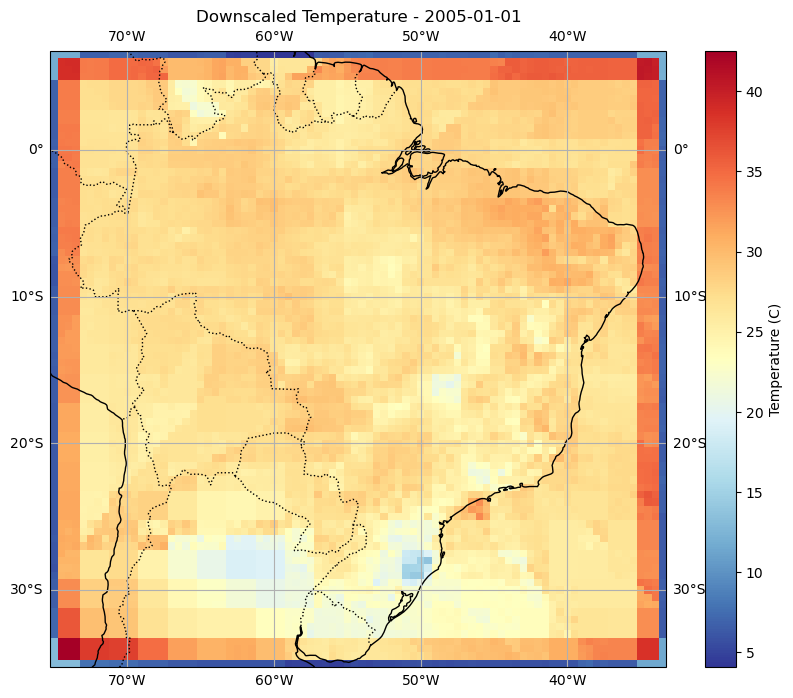

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data
downscaled.sel(time='2005-01-01').tas.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (C)'}
)

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.gridlines(draw_labels=True)

ax.set_title('Downscaled Temperature - 2005-01-01')
plt.show()

In [ ]:
# Read in full municipality shapefile
shapefile = gpd.read_file("shapefile_data/RG2017_rgi.shp")

# Set index for exactextract
rgi_indexed = shapefile.set_index("rgi")

In [119]:
salvador = shapefile[shapefile['nome_rgi'] == 'Salvador']

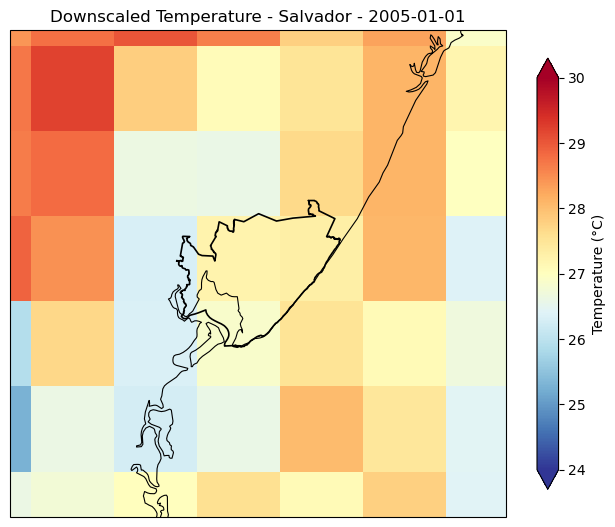

In [137]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Get bounds from the Salvador shapefile
bounds = salvador.total_bounds  # [minx, miny, maxx, maxy]
pad = 1.0  # degrees of padding around the region

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot downscaled temperature for a single time step
downscaled.sel(time='2005-01-01').tas.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (°C)', 'shrink': 0.7},
    vmin = 24,
    vmax = 30,
    zorder=1
)

# Overlay Salvador boundary
salvador.boundary.plot(ax=ax, color='black', linewidth=1.2, transform=ccrs.PlateCarree())

# Zoom to Salvador domain
ax.set_extent([bounds[0] - pad, bounds[2] + pad, bounds[1] - pad, bounds[3] + pad])

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
# ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--', color='gray')

ax.set_title('Downscaled Temperature - Salvador - 2005-01-01')
plt.show()


In [ ]:
# TODO: fix plotting alignment miss match
# TODO: plot the same for non-downscaled data in Salvador

In [135]:
print(salvador.crs)

EPSG:4674


In [129]:
print("Shapefile CRS:", salvador.crs)
print("Bounds:", salvador.total_bounds)
print("Downscaled lon range:", float(downscaled.lon.min()), float(downscaled.lon.max()))
print("Downscaled lat range:", float(downscaled.lat.min()), float(downscaled.lat.max()))


Shapefile CRS: EPSG:4674
Bounds: [-38.87742889 -13.0172961  -37.89135998 -12.15778465]
Downscaled lon range: -74.5 -34.0
Downscaled lat range: -34.5 6.0


In [ ]:
# load population density data

pop_density = xr.open_dataarray("population_density_05deg_demo.nc").isel(lon=slice(0,82))

pop_density = pop_density.rio.write_crs("EPSG:4674", inplace=True)

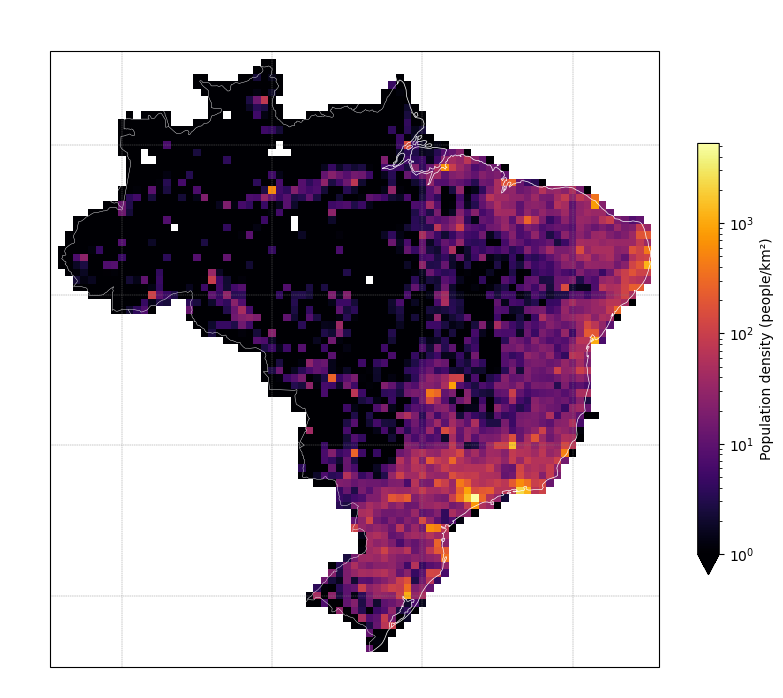

In [ ]:
# plot population density data

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

pop_density.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    norm=LogNorm(vmin=1, vmax=float(pop_density.max())),
    cmap='inferno',
    cbar_kwargs={'label': 'Population density (people/km²)', 'shrink': 0.7}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.3, edgecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--', color='gray')
gl.xlabel_style = {'color': 'white'}
gl.ylabel_style = {'color': 'white'}

ax.set_title('Population Density', color='white')
plt.show()


In [18]:
# Convert 3D obs into list of 2D rasters (one per time step)
downscaled_list = [downscaled.isel(time=i).drop_vars("time") for i in range(downscaled.sizes["time"])]
times = downscaled.time.values

In [ ]:
# Align spatial reference systems
downscaled.rio.write_crs("EPSG:4674", inplace=True)

# Convert 3D obs into list of 2D rasters (one per time step)
downscaled_list = [downscaled.isel(time=i).drop_vars("time") for i in range(downscaled.sizes["time"])]
times = downscaled.time.values

In [84]:
times[3652]

np.datetime64('2009-12-31T00:00:00.000000000')

In [ ]:
def process_time_step(i,rgi='Salvador',times=times,rgi_indexed=rgi_indexed,downscaled=downscaled,pop_density=pop_density):
    """
    Extract the population-weighted mean daily temperature for a given region
    at a given time step.

    Parameters
    ----------
    i : int
        Index of the time step to process.
    rgi : str, optional
        Name of the region of interest (matched against the 'nome_rgi' column).
        Defaults to 'Salvador'.
    times : array-like
        Array of time values corresponding to the downscaled dataset.
    rgi_indexed : GeoDataFrame
        Shapefile GeoDataFrame indexed by 'rgi' code.
    downscaled : xr.Dataset
        Downscaled temperature dataset with dimensions (time, lat, lon).
    pop_density : xr.DataArray
        Population density raster used as weights.

    Returns
    -------
    float
        Population-weighted mean temperature for the specified region
        at time step i.
    """
    date = str(times[i])
    print(f"Processing time step {i+1}/{len(times[:3562])}", end='\r', flush=True)

    # Rename coordinates
    downscaled_i = downscaled.isel(time=i).rename({"lat": "y", "lon": "x"})
    # data_renamed = downscaled_list[i].rename({"lat": "y", "lon": "x"})
    pop_renamed = pop_density.rename({"lat": "y", "lon": "x"})
    
    # select rgi of interest
    rgi_of_interest = rgi_indexed[rgi_indexed.nome_rgi == rgi]

    # Extract both unweighted and weighted means
    df = exact_extract(
        downscaled_i,
        rgi_of_interest,
        ['mean(coverage_weight=area_spherical_m2)', 'weighted_mean(coverage_weight=area_spherical_m2)'],
        weights=pop_renamed,
        output='pandas'
    )
    
    return df['weighted_mean'].values[0]


In [ ]:
# generate the population weighted mean daily temperature timeseries for Salvador

salvador_timeseries = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, rgi='Salvador') for i in range(len(times[:3562]))]
}, index=times[:3562])

<Axes: >

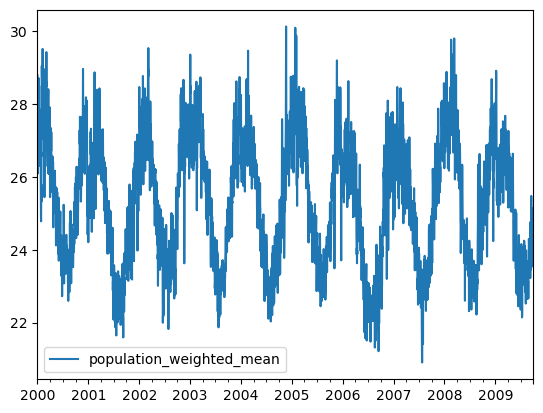

In [115]:
salvador_timeseries.plot()